# Nuclear NPV simulation

Run the nuclear electricity Monte Carlo simulation and visualize the resulting NPV distribution.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity.electricity_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_SAMPLE_SIZE,
    simulate_electricity_results,
)


In [2]:
TECHNOLOGY = 'nuclear'
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED

results_by_technology = simulate_electricity_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
)
simulation = results_by_technology[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()


,run_id,technology,annual_output_mwh,full_load_hours_per_year,lifetime_years,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,...,initial_capex_eur,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_mwh,npv_eur_per_mwh
0,0,nuclear,1000000.0,7900.0,45.0,126.582278,126582.278481,15724.587499,102.953740,6.987695,...,1.990454e+09,94070000.0,1.303212e+07,6.987695e+06,2.256930e+07,0.0,5.148088e+07,-1.367103e+09,45000000.0,-30.380065
1,1,nuclear,1000000.0,7900.0,45.0,126.582278,126582.278481,15964.531102,97.379906,6.372797,...,2.020827e+09,94070000.0,1.232657e+07,6.372797e+06,2.390292e+07,0.0,5.146771e+07,-1.397635e+09,45000000.0,-31.058557
2,2,nuclear,1000000.0,7900.0,45.0,126.582278,126582.278481,7427.021501,101.561229,6.895060,...,9.401293e+08,94070000.0,1.285585e+07,6.895060e+06,2.241226e+07,0.0,5.190682e+07,-3.116206e+08,45000000.0,-6.924903
3,3,nuclear,1000000.0,7900.0,45.0,126.582278,126582.278481,6065.722358,97.025903,8.171383,...,7.678130e+08,94070000.0,1.228176e+07,8.171383e+06,2.212474e+07,0.0,5.149212e+07,-1.443257e+08,45000000.0,-3.207239
4,4,nuclear,1000000.0,7900.0,45.0,126.582278,126582.278481,9114.025618,116.206434,7.746482,...,1.153674e+09,94070000.0,1.470968e+07,7.746482e+06,2.314142e+07,0.0,4.847242e+07,-5.667506e+08,45000000.0,-12.594458


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_mwh = results["npv_eur_per_mwh"]
summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/MWh"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/MWh
count,100000.000000,100000.000000
mean,-777.127836,-17.269507
std,365.127608,8.113947
min,-1457.863145,-32.396959
5%,-1346.534717,-29.922994
50%,-776.139145,-17.247537
95%,-208.473227,-4.632738
max,-95.091055,-2.113135


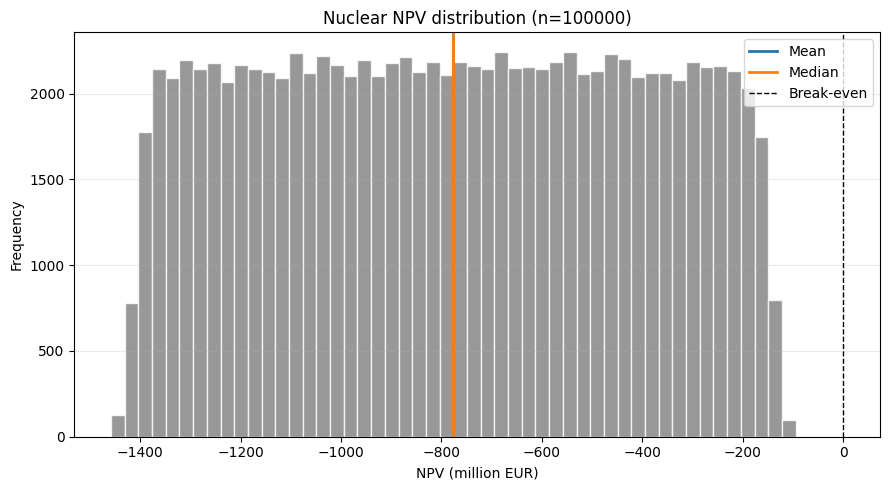

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Nuclear NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

## NPV per MWh histogram


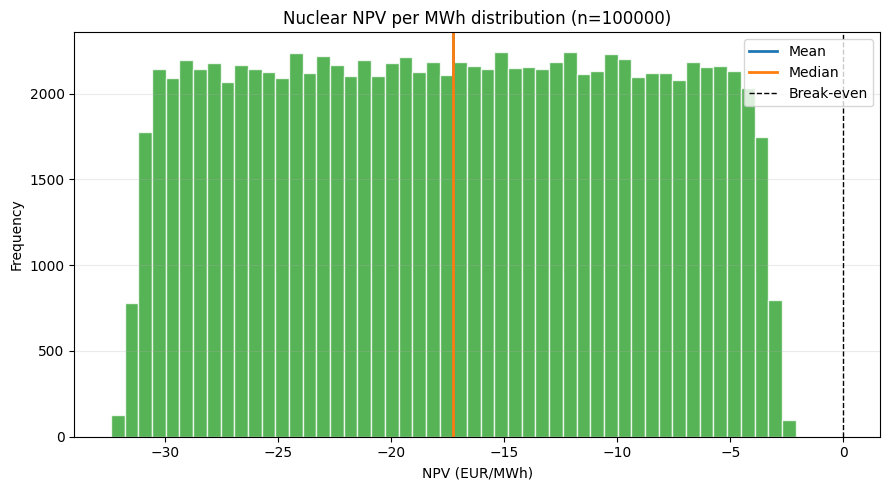

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Nuclear NPV per MWh distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.070000
annual_fixed_opex_eur        13.080129
annual_variable_opex_eur      7.230404
annual_fuel_cost_eur         22.880993
annual_emissions_cost_eur     0.000000
annual_net_cash_flow_eur     50.878474
Name: Mean annual value, million EUR, dtype: float64